# Quantum metric from Wannier models — position-resolved
If a site of the second hop coincides with a site of the first
(A = B, A = C, D = B or D = C), the second hop is pinned to within one hop of the first.
Those terms are then enumerated one by one.
Every other piece is an ordinary k-space sum, with no positions needed.

**Note:** the values in the paper (Fig. 2, Tables S4–S6) were computed with this method at `min_hopping_norm = 1e-4` eV and `nk` = 48 (NaCl), 46 (diamond), 15 (CsI$_3$), 42 (GeTe), which needs a cluster; those results are in `cluster_outputs/`. The defaults below (0.01 eV, `nk` = 30) run locally in about a minute.

In [1]:
#Import everything
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
import os
import re
import warnings
from tqdm import tqdm
from pymatgen.io.vasp.outputs import Outcar
import pythtb
from pythtb import * # import TB model class
try:
    W90            # pythtb >= 2.0
except NameError:
    W90 = w90      # pythtb 1.8 calls the same class w90
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious numpy 2.x / macOS Accelerate warnings
print("pythtb", pythtb.__version__)

pythtb 2.0.0


## 1. Create pythTB model from Wannier90 

In [ ]:
#Create pythTB from wannier
material = "GeTe"            # NaCl, Diamond, CsI3, GeTe
wann_dir = "data/" + material
min_hopping_norm = 0.01      # eV  (paper: 1e-4, cluster)
nk = 30                      # primitive mesh nk^3 (30 = 2x2x2 supercell with 15^3)

OUTCAR = Outcar(wann_dir+"/OUTCAR")
mu = OUTCAR.efermi
wannier_material = W90(wann_dir, r"wannier90")
my_model = wannier_material.model(min_hopping_norm=min_hopping_norm)  # drop hoppings with |t| < min_hopping_norm

## 2. Create array with all hopping information


In [3]:
#Create array with all hopping information
if hasattr(my_model, "orb_vecs"):                     # pythtb 2.x (as in Quantum_Metric_Wannier.ipynb)
    lat = np.array(my_model.lattice.lat_vecs)         # lattice vectors (rows), Angstrom
    orb_red = np.array(my_model.orb_vecs)
    hoppings = [(hop['amplitude'], hop['from_orbital'], hop['to_orbital'], hop.get('lattice_vector', [0,0,0]))
                for hop in my_model.hoppings]
else:                                                 # pythtb 1.8
    lat = np.array(my_model.get_lat())
    orb_red = np.array(my_model.get_orb())
    hoppings = [(hop[0], hop[1], hop[2], hop[3]) for hop in my_model._hoppings]
orb_pos = orb_red @ lat                               # Wannier centres, cartesian
norb = len(orb_pos)
onsite = np.real(np.array(my_model._site_energies, dtype=complex))

hop_from, hop_to, hop_R, hop_t = [], [], [], []
for t, i, j, j_image in hoppings:
    j_image = np.array(j_image, dtype=int)
    hop_from += [i, j];  hop_to += [j, i]             # i -> j+R  and its partner  j -> i-R
    hop_R += [j_image, -j_image]
    hop_t += [t, np.conj(t)]
hop_from = np.array(hop_from); hop_to = np.array(hop_to)
hop_R = np.array(hop_R); hop_t = np.array(hop_t, dtype=complex)
hop_disp = (hop_R + orb_red[hop_to] - orb_red[hop_from]) @ lat   # d = R + tau_j - tau_i  (notebook: dist)
hop_vel = 1j * hop_disp * hop_t[:, None]                        # v^mu = i d^mu t   (shape: nhop x 3)
print(norb, "orbitals,", len(hop_t), "directed hoppings,  longest hop %.2f A" % np.linalg.norm(hop_disp, axis=1).max())

8 orbitals, 986 directed hoppings,  longest hop 12.24 A


## 3. Which atom each orbital belongs to

In [ ]:
#Order of pythTB orbitals
ORB_MULT = {"s": 1, "p": 3, "d": 5, "f": 7, "sp": 2, "sp2": 3, "sp3": 4, "sp3d": 5, "sp3d2": 6}   # px, dxy, ... count 1

def win_block(txt, name):
    m = re.search(r"begin\s+" + name + r"\s*\n(.*?)\nend\s+" + name, txt, re.S | re.I)
    return [l.split("!")[0].split("#")[0].split() for l in m.group(1).splitlines()] if m else None

win = open(wann_dir + "/wannier90.win").read()
rows = [r for r in (win_block(win, "atoms_cart") or win_block(win, "atoms_frac")) if r]
species = [r[0] for r in rows]
atom_pos = np.array([r[1:4] for r in rows], float)
if win_block(win, "atoms_cart") is None:
    atom_pos = atom_pos @ lat                                           # atoms_frac -> cartesian

orb_atom = []
for r in win_block(win, "projections"):
    if not r: continue
    site, orbs = r[0].split(":")[:2]                                    # e.g. "Ge:s,p"  (site:ang_mtm[:zaxis:...])
    assert "=" not in site, "f=/c= site projections are not handled; use species:orbitals lines"
    n_orb = sum(ORB_MULT.get(o.strip().lower(), 1) for o in re.split("[,;]", orbs))
    orb_atom += [a for a, s in enumerate(species) if s == site for _ in range(n_orb)]   # atom index, repeated n_orb times
orb_atom = np.array(orb_atom)
assert len(orb_atom) == norb, f"projections block gives {len(orb_atom)} orbitals, model has {norb}"

# A Wannier centre may be written in a neighbouring cell (e.g. z = -0.06 while the atom is at z = 10.98 = c - 0.06):
# the cell of the orbital is the lattice translation that brings its atom next to the centre.
orb_cell = np.round((orb_pos - atom_pos[orb_atom]) @ np.linalg.inv(lat)).astype(int)
orb_dist = np.linalg.norm(orb_pos - atom_pos[orb_atom] - orb_cell @ lat, axis=1)
assert orb_dist.max() < 1.0, "a Wannier centre is more than 1 A from its projection atom: check the projections block"

pd.DataFrame({"orbital": range(norb), "atom": [f"{species[a]}{a}" for a in orb_atom],
              "cell": [tuple(c) for c in orb_cell], "|centre - atom| (A)": orb_dist.round(3)})


## 4. Hamiltonian and velocity on the k-mesh


In [ ]:

def ham_func(kpts, hop_mask=None):
    """H(k) and v_mu(k) = dH/dk_mu for an array of cartesian k-points (shape nk x 3)."""
    sel = np.ones(len(hop_t), bool) if hop_mask is None else hop_mask
    phase = np.exp(1j * kpts @ hop_disp[sel].T) * hop_t[sel]           # (nk, nhop): t e^{ik.d}
    to_matrix = np.zeros((sel.sum(), norb * norb))                     # hopss -> matrix element (i, j)
    to_matrix[np.arange(sel.sum()), hop_from[sel] * norb + hop_to[sel]] = 1
    H = (phase @ to_matrix).reshape(-1, norb, norb)
    V = np.stack([((1j * hop_disp[sel, c] * phase) @ to_matrix).reshape(-1, norb, norb) for c in range(3)])
    if hop_mask is None:
        H = H + np.diag(onsite)
    return H, V

def ham_func_chunked(kpts, hop_mask=None, chunk=2000):
    out = [ham_func(kpts[s:s + chunk], hop_mask) for s in range(0, len(kpts), chunk)]
    return np.concatenate([o[0] for o in out]), np.concatenate([o[1] for o in out], axis=1)


recip = 2 * np.pi * np.linalg.inv(lat).T                                 
g = (np.arange(nk) + 0.5) / nk
k_frac = np.array(np.meshgrid(g, g, g, indexing="ij")).reshape(3, -1).T
kSpan = k_frac @ recip                                                  # cartesian k, nk^3 points
H_k, V_k = ham_func_chunked(kSpan)
E_k, U_k = np.linalg.eigh(H_k)                                         # U_k[k, orbital, band]

occ = int(np.bincount((E_k < mu).sum(1)).argmax())                     # occupied bands
vbm, cbm = E_k[:, occ - 1].max(), E_k[:, occ].min()
mu0 = 0.5 * (vbm + cbm)
print("mu", mu)
print("occ", occ)
print("VBM %.4f  CBM %.4f  gap %.4f eV  (mu0 = %.4f)" % (vbm, cbm, cbm - vbm, mu0))
assert cbm > vbm, "no gap at this min_hopping_norm: occupied/empty split is not defined"

mu 5.9873
occ 5
VBM 5.6944  CBM 6.1969  gap 0.5025 eV  (mu0 = 5.9456)


## 5. The k-space sums 

In [6]:
#Intra-atomic hops: start site == end site
start_atom, start_cell = orb_atom[hop_from], orb_cell[hop_from]
end_atom,   end_cell   = orb_atom[hop_to],   hop_R + orb_cell[hop_to]
intra = (start_atom == end_atom) & (start_cell == end_cell).all(1)
print(intra.sum(), "intra-atomic hops (A = D)")
_, Vintra_k = ham_func_chunked(kSpan, hop_mask=intra) if intra.any() else (None, np.zeros_like(V_k))

#k-space sums
Uo, Ue = U_k[:, :, :occ], U_k[:, :, occ:]
w = 1.0 / (E_k[:, None, occ:] - E_k[:, :occ, None]) ** 2                # w[k, i occ, j emp]
denom = len(kSpan) * occ
kspace = {key: np.zeros(3, complex) for key in ("T", "S_AD", "S_BC", "S_ADBC")}
for c in range(3):
    v  = np.einsum("kai,kab,kbj->kij", Uo.conj(), V_k[c], Ue)          # <i|v|j>, all hops
    vi = np.einsum("kai,kab,kbj->kij", Uo.conj(), Vintra_k[c], Ue)     # <i|v|j>, intra-atomic hops only
    kspace["T"][c]      = (w * v  * v.conj()).sum()  / denom
    kspace["S_AD"][c]   = (w * vi * v.conj()).sum()  / denom
    kspace["S_BC"][c]   = (w * v  * vi.conj()).sum() / denom
    kspace["S_ADBC"][c] = (w * vi * vi.conj()).sum() / denom
print("total quantum metric  xx %.5f  yy %.5f  zz %.5f   Tr g = %.5f A^2 per electron"
      % (*kspace["T"].real, kspace["T"].real.sum()))

4 intra-atomic hops (A = D)


total quantum metric  xx 1.06714  yy 1.08209  zz 0.96133   Tr g = 3.11056 A^2 per electron


## 6. Enumerate the 2- and 3-center shared site terms


In [ ]:
def canonicalize(combo):
    mapping = {}
    next_label = ord('a')
    result = []
    for x in combo:
        if x not in mapping:
            mapping[x] = chr(next_label)
            next_label += 1
        result.append(mapping[x])
    return ''.join(result)

all_patterns = sorted({canonicalize(p) for p in itertools.product(range(4), repeat=4)})   # the 15 patterns
def equality_code(A, D, B, C):
    eq = [A == D, A == B, A == C, D == B, D == C, B == C]
    return sum(np.asarray(e).astype(int) << n for n, e in enumerate(eq))
code_to_pattern = {equality_code(*p): p for p in all_patterns}

CLASS = {'abba': '2-center polarization', 'abab': '2-center transfer',
         'abbc': '3-center', 'abcb': '3-center', 'abac': '3-center', 'abca': '3-center', 'abcd': '4-center'}
def pattern_class(p):
    return CLASS.get(p, 'other (A=D or B=C)')

def site_id(atom, cell):
    """one integer per (atom, cell), so sites can be compared with =="""
    cell = np.asarray(cell) + 512
    return ((np.asarray(atom) * 1024 + cell[..., 0]) * 1024 + cell[..., 1]) * 1024 + cell[..., 2]

coincidence_types = [("A=B", "start", "start"), ("A=C", "start", "end"),
                     ("D=B", "end", "start"),   ("D=C", "end", "end")]

def shared_site_terms(chunk=200000):
    """Yield chunks of shared-site terms: (h1, h2, RB, code); every term exactly once."""
    for n_type, (name, side1, side2) in enumerate(coincidence_types):
        for alpha in range(len(atom_pos)):
            h1_all = np.where((start_atom if side1 == "start" else end_atom) == alpha)[0]
            h2     = np.where((start_atom if side2 == "start" else end_atom) == alpha)[0]
            step = max(1, chunk // max(len(h2), 1))
            for s in range(0, len(h1_all), step):
                h1 = np.repeat(h1_all[s:s + step], len(h2))           # all (h1, h2) pairs of this chunk
                h2p = np.tile(h2, len(h1_all[s:s + step]))
                a, d, hD = hop_from[h1], hop_to[h1], hop_R[h1]
                b, c, hC = hop_from[h2p], hop_to[h2p], hop_R[h2p]
                if name == "A=B":   RB = orb_cell[a] - orb_cell[b]
                elif name == "A=C": RB = orb_cell[a] - orb_cell[c] - hC
                elif name == "D=B": RB = hD + orb_cell[d] - orb_cell[b]
                else:               RB = hD + orb_cell[d] - orb_cell[c] - hC
                A = site_id(orb_atom[a], orb_cell[a])
                D = site_id(orb_atom[d], hD + orb_cell[d])
                B = site_id(orb_atom[b], RB + orb_cell[b])
                C = site_id(orb_atom[c], RB + hC + orb_cell[c])
                earlier = [A == B, A == C, D == B, D == C][:n_type]  # coincidences of earlier types
                keep = ~np.any(earlier, axis=0) if earlier else np.ones(len(h1), bool)
                yield h1[keep], h2p[keep], RB[keep], equality_code(A, D, B, C)[keep]

n_terms = sum(len(t[0]) for t in shared_site_terms())
print(n_terms, "shared-site terms")

1917484 shared-site terms


## 7. Evaluate the shared-site terms in real space

The energy denominator couples occupied and empty bands. To split it, write it as a time integral:

$$\frac{1}{(E_j-E_i)^2} = \int_0^\infty t\,e^{-t(E_j-\mu_0)}\,e^{-t(\mu_0-E_i)}\,dt$$

Both exponentials decay, because $E_i < \mu_0 < E_j$. For each time $t$ this gives two real-space density matrices:

$$\rho_\mathrm{occ}(t) = \sum_{i\in\mathrm{occ}} e^{+t(E_i-\mu_0)}|i\rangle\langle i|, \qquad
\rho_\mathrm{emp}(t) = \sum_{j\in\mathrm{emp}} e^{-t(E_j-\mu_0)}|j\rangle\langle j|$$

so a term is

$$X = \int_0^\infty t\,dt\;\; v_{AD}\;\rho_\mathrm{emp}(t)_{DB}\;v_{BC}\;\rho_\mathrm{occ}(t)_{CA}$$

with $A$ in the home cell (this gives the value per unit cell). The integral is a sum over a log-spaced grid of `t`
(`t_weights`); the printed quadrature error is the worst case over all energy differences.

`rho[t, o, o', R]` = ⟨o, cell R | ρ(t) | o', home cell⟩, the Fourier transform of $U g(t) U^\dagger$ over the mesh.
Two phase factors appear:
- $e^{ik(\tau_o-\tau_{o'})}$, because `ham_func` puts the orbital positions in the phase ($d = R+\tau_j-\tau_i$);
- $e^{i\pi(R_1+R_2+R_3)/n_k}$, because the mesh is shifted by half a step.

The two density matrices a term needs are
- ρ_emp from D (orbital d, cell hD) to B (orbital b, cell RB): `rho_emp[:, d, b, hD − RB]`
- ρ_occ from C (orbital c, cell RB + hC) to A (orbital a, cell 0): `rho_occ[:, c, a, RB + hC]`

The FFT only resolves cells up to (nk−1)/2 without aliasing. So we first list the cells actually needed, then check them.

In [8]:
#Time grid for 1/dE^2 = int t e^{-t dE} dt   (log spaced: t = e^s, dt = t ds)
t_step = 0.3
Wmax = E_k.max() - E_k.min()
gap_direct = (E_k[:, occ] - E_k[:, occ - 1]).min()
s = np.arange(np.log(1e-3 / Wmax), np.log(60.0 / gap_direct) + t_step, t_step)
t_grid = np.exp(s)
t_weights = t_step * t_grid ** 2                                           # t dt = t^2 ds
dE_test = np.linspace(cbm - vbm, Wmax, 400)
quad_err = np.abs((t_weights * np.exp(-np.outer(dE_test, t_grid))).sum(1) * dE_test ** 2 - 1).max()
print(len(t_grid), "time points,  quadrature max relative error %.1e" % quad_err)

#Cells where the density matrices are needed
needed = set()
for h1, h2, RB, code in shared_site_terms():
    needed.update(map(tuple, np.unique(hop_R[h1] - RB, axis=0)))
    needed.update(map(tuple, np.unique(RB + hop_R[h2], axis=0)))
cells = np.array(sorted(needed))
Rmax = np.abs(cells).max()
print(len(cells), "cells, largest index", Rmax)
assert Rmax <= (nk - 1) // 2, f"k-mesh too small: need nk > {2 * Rmax}"
cell_index = {tuple(R): n for n, R in enumerate(cells)}

#Real-space density matrices rho[t, o, o', cell]
orb_phase = np.exp(1j * kSpan @ orb_pos.T)                                 # e^{ik.tau_o}
P = orb_phase[:, :, None] * orb_phase.conj()[:, None, :]                   # e^{ik(tau_o - tau_o')}
fft_index = tuple((cells % nk).T)
shift_phase = np.exp(1j * np.pi * cells.sum(1) / nk)                       # half-step mesh shift
rho_occ = np.zeros((len(t_grid), norb, norb, len(cells)), complex)
rho_emp = np.zeros_like(rho_occ)
for it, t in enumerate(tqdm(t_grid)):
    for rho, bands, gt in ((rho_occ, slice(0, occ), np.exp(+t * (E_k[:, :occ] - mu0))),
                           (rho_emp, slice(occ, None), np.exp(-t * (E_k[:, occ:] - mu0)))):
        Ub = U_k[:, :, bands]
        rho_k = np.einsum("kai,ki,kbi->kab", Ub, gt, Ub.conj()) * P          # U g(t) U^dagger
        F = np.fft.ifftn(rho_k.reshape(nk, nk, nk, norb, norb), axes=(0, 1, 2))   # (1/N) sum_k e^{ik.R}
        rho[it] = (F[fft_index] * shift_phase[:, None, None]).transpose(1, 2, 0)

49 time points,  quadrature max relative error 3.6e-07


513 cells, largest index 4



  0%|          | 0/49 [00:00<?, ?it/s]


  2%|▏         | 1/49 [00:00<00:04,  9.83it/s]


  6%|▌         | 3/49 [00:00<00:04, 11.15it/s]

...


 88%|████████▊ | 43/49 [00:03<00:00, 11.71it/s]


 92%|█████████▏| 45/49 [00:03<00:00, 11.70it/s]


 96%|█████████▌| 47/49 [00:04<00:00, 11.75it/s]


100%|██████████| 49/49 [00:04<00:00, 11.78it/s]


100%|██████████| 49/49 [00:04<00:00, 11.66it/s]

In [9]:
#Evaluate every shared-site term and add it to its pattern
collect_motifs = True        # also keep each 2-/3-center term by geometry (section 10)
pattern_sum = {p: np.zeros(3, complex) for p in all_patterns}
enum_AD = np.zeros(3, complex); enum_BC = np.zeros(3, complex); enum_ADBC = np.zeros(3, complex)
motif_rows = []
for h1, h2, RB, code in tqdm(shared_site_terms()):
    a, d, hD = hop_from[h1], hop_to[h1], hop_R[h1]
    b, c, hC = hop_from[h2], hop_to[h2], hop_R[h2]
    i1 = np.array([cell_index[tuple(R)] for R in hD - RB])
    i2 = np.array([cell_index[tuple(R)] for R in RB + hC])
    K = np.einsum("t,tp,tp->p", t_weights, rho_emp[:, d, b, i1], rho_occ[:, c, a, i2])   # int t dt rho_emp rho_occ
    value = hop_vel[h1] * hop_vel[h2] * K[:, None] / occ                  # (terms, 3): xx, yy, zz
    for cd in np.unique(code):
        pattern_sum[code_to_pattern[cd]] += value[code == cd].sum(0)
    AD, BC = (code & 1) > 0, (code & 32) > 0                              # bit 0: A=D, bit 5: B=C
    enum_AD += value[AD].sum(0); enum_BC += value[BC].sum(0); enum_ADBC += value[AD & BC].sum(0)
    if collect_motifs:
        site_cells = np.stack([orb_cell[a], hD + orb_cell[d], RB + orb_cell[b], RB + hC + orb_cell[c]], 1)
        site_cells = site_cells - site_cells[:, :1]                         # cells relative to A
        key = np.concatenate([code[:, None], np.stack([orb_atom[a], orb_atom[d], orb_atom[b], orb_atom[c]], 1),
                              site_cells.reshape(len(code), -1)], 1)
        uk, inv = np.unique(key, axis=0, return_inverse=True)
        summed = np.zeros((len(uk), 3)); np.add.at(summed, inv.ravel(), value.real)
        motif_rows.append(np.concatenate([uk, summed], 1))


0it [00:00, ?it/s]


1it [00:00,  1.26it/s]


2it [00:01,  2.22it/s]


3it [00:01,  1.67it/s]


5it [00:02,  2.06it/s]

...


11it [00:05,  2.10it/s]


13it [00:05,  2.26it/s]


14it [00:06,  2.60it/s]


15it [00:06,  2.18it/s]


16it [00:06,  2.30it/s]

## 8. The remaining patterns from the k-space sums

Every term with A = D is in `S_AD`. The ones that also share a site between the two hops were enumerated in section 7
(and labelled there). The rest have A = D, no shared site, and B ≠ C (`aabc`), or B = C (`aabb`). The same holds for B = C.

    aabb = S_ADBC − (enumerated terms with A=D and B=C)
    aabc = S_AD   − (enumerated terms with A=D) − aabb
    abcc = S_BC   − (enumerated terms with B=C) − aabb

Whatever is left of the total has four distinct sites:

    abcd (4-center) = T − all other patterns

That is why the 4-center class is exact as a total, but individual 4-center motifs are not listed
(`position_resolved/validate_4center.py` computes the largest ones separately).

In [10]:
QM = dict(pattern_sum)
QM['aabb'] = kspace['S_ADBC'] - enum_ADBC
QM['aabc'] = kspace['S_AD'] - enum_AD - QM['aabb']
QM['abcc'] = kspace['S_BC'] - enum_BC - QM['aabb']
QM['abcd'] = kspace['T'] - sum(v for p, v in QM.items() if p != 'abcd')
print("sum of patterns %.6f = k-space total %.6f" % (sum(QM.values()).real.sum(), kspace['T'].real.sum()))
print("largest imaginary part %.1e (should be ~0)" % max(abs(v.imag).max() for v in QM.values()))

sum of patterns 3.110562 = k-space total 3.110562
largest imaginary part 3.3e-17 (should be ~0)


## 9. Tables 

In [11]:
def old_label(p):                    # paper order (A, D, B, C) -> tensor order (A, B, C, D)
    return canonicalize((p[0], p[2], p[3], p[1]))

patterns_df = pd.DataFrame([dict(pattern=p, old_label=old_label(p), cls=pattern_class(p),
                                 xx=QM[p][0].real, yy=QM[p][1].real, zz=QM[p][2].real, trace=QM[p].real.sum())
                            for p in all_patterns])
classes_df = patterns_df.groupby('cls')[['xx', 'yy', 'zz', 'trace']].sum()
classes_df = classes_df.reindex(['2-center polarization', '2-center transfer', '3-center', '4-center', 'other (A=D or B=C)'])
classes_df.loc['total, Tr g'] = classes_df.sum()
classes_df.round(4)

,xx,yy,zz,trace
cls,,,,
2-center polarization,0.5356,0.5468,0.5545,1.6369
2-center transfer,0.0642,0.0687,0.0534,0.1863
3-center,0.2076,0.2074,0.1913,0.6063
4-center,0.2598,0.2592,0.1621,0.6811
other (A=D or B=C),-0.0000,0.0000,0.0000,0.0000
"total, Tr g",1.0671,1.0821,0.9613,3.1106


In [12]:
data1, data2, data3, data4 = [], [], [], []
for p in all_patterns:
    row = [p, QM[p].real.sum()]
    [data1, data2, data3, data4][len(set(p)) - 1].append(row)
df1 = pd.DataFrame(data=data1, columns=['1orb', 'QM1orb'])
df2 = pd.DataFrame(data=data2, columns=['2orb', 'QM2orb'])
df3 = pd.DataFrame(data=data3, columns=['3orb', 'QM3orb'])
df4 = pd.DataFrame(data=data4, columns=['4orb', 'QM4orb'])
df = pd.concat([df1, df2, df3, df4], axis=1)
out_file = wann_dir + '/position_resolved_QM_trace_notebook.xlsx'
try:
    with pd.ExcelWriter(out_file) as writer:
        df.to_excel(writer, sheet_name='trace', index=False)
        patterns_df.to_excel(writer, sheet_name='patterns', index=False)
        classes_df.to_excel(writer, sheet_name='classes')
except ImportError:                  # no openpyxl/xlsxwriter in this environment: write csv instead
    out_file = out_file.replace('.xlsx', '_patterns.csv')
    patterns_df.to_csv(out_file, index=False)
print("wrote", out_file)
print(sum(QM.values()).real.sum())
df

,1orb,QM1orb,2orb,QM2orb,3orb,QM3orb,4orb,QM4orb
0,aaaa,5.844610e-09,aaab,1.483199e-05,aabc,0.000010,abcd,0.681072
1,NaN,NaN,aaba,-1.090046e-05,abac,-0.020602,NaN,NaN
2,NaN,NaN,aabb,-7.773070e-10,abbc,0.085329,NaN,NaN
3,NaN,NaN,abaa,-1.090046e-05,abca,0.562137,NaN,NaN
4,NaN,NaN,abab,1.863275e-01,abcb,-0.020602,NaN,NaN
5,NaN,NaN,abba,1.636872e+00,abcc,0.000010,NaN,NaN
6,NaN,NaN,abbb,1.483199e-05,NaN,NaN,NaN,NaN


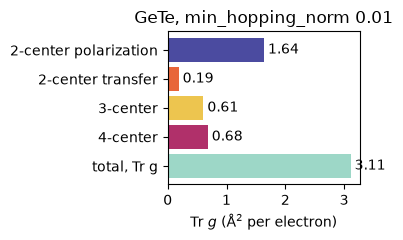

In [13]:
#Bars (Fig. 2 l style)
order = ['2-center polarization', '2-center transfer', '3-center', '4-center', 'total, Tr g']
vals = classes_df.loc[order, 'trace']
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.barh(order[::-1], vals[::-1], color=['#9DD7C7', '#B0306A', '#EDC54F', '#E8663A', '#4B4BA0'])
for i, v in enumerate(vals[::-1]):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.set_xlabel(r'Tr $g$ (Å$^2$ per electron)'); ax.set_title(f'{material}, min_hopping_norm {min_hopping_norm:g}')
plt.tight_layout()

## 10. Largest individual 2- and 3-center fluctuations 

In [14]:
motifs = pd.DataFrame(np.concatenate(motif_rows), columns=['code', 'A', 'D', 'B', 'C'] +
                      [f'{s}{x}' for s in 'ADBC' for x in 'xyz'] + ['xx', 'yy', 'zz'])
key_cols = list(motifs.columns[:-3])
motifs = motifs.groupby(key_cols, as_index=False)[['xx', 'yy', 'zz']].sum()     # merge chunks
motifs['pattern'] = [code_to_pattern[int(c)] for c in motifs['code']]
motifs['class'] = motifs['pattern'].map(pattern_class)
motifs['trace'] = motifs[['xx', 'yy', 'zz']].sum(axis=1)
for s in 'ADBC':
    atom = motifs[s].astype(int)
    cell = motifs[[f'{s}x', f'{s}y', f'{s}z']].to_numpy(int)
    motifs[f'pos{s}'] = list(atom_pos[atom] + cell @ lat)
    motifs[f'site{s}'] = [f"{species[a]}{a}@{tuple(int(x) for x in c)}" for a, c in zip(atom, cell)]
motifs['d_AD'] = [np.linalg.norm(q - p) for p, q in zip(motifs['posA'], motifs['posD'])]
motifs['d_BC'] = [np.linalg.norm(q - p) for p, q in zip(motifs['posB'], motifs['posC'])]
motifs = motifs.sort_values('trace', key=np.abs, ascending=False)
motifs[['pattern', 'class', 'siteA', 'siteD', 'siteB', 'siteC', 'd_AD', 'd_BC', 'trace']].head(20).round(4)

,pattern,class,siteA,siteD,siteB,siteC,d_AD,d_BC,trace
27786,abba,2-center polarization,"Te1@(0, 0, 0)","Ge0@(0, 0, -1)","Ge0@(0, 0, -1)","Te1@(0, 0, 0)",2.8415,2.8415,0.2690
27783,abba,2-center polarization,"Te1@(0, 0, 0)","Ge0@(0, -1, 0)","Ge0@(0, -1, 0)","Te1@(0, 0, 0)",2.8415,2.8415,0.2616
27775,abba,2-center polarization,"Te1@(0, 0, 0)","Ge0@(-1, 0, 0)","Ge0@(-1, 0, 0)","Te1@(0, 0, 0)",2.8415,2.8415,0.2616
27774,abba,2-center polarization,"Te1@(0, 0, 0)","Ge0@(-1, 0, -1)","Ge0@(-1, 0, -1)","Te1@(0, 0, 0)",3.2609,3.2609,0.1487
27782,abba,2-center polarization,"Te1@(0, 0, 0)","Ge0@(0, -1, -1)","Ge0@(0, -1, -1)","Te1@(0, 0, 0)",3.2609,3.2609,0.1487
27772,abba,2-center polarization,"Te1@(0, 0, 0)","Ge0@(-1, -1, 0)","Ge0@(-1, -1, 0)","Te1@(0, 0, 0)",3.2609,3.2609,0.1456
25065,abbc,3-center,"Te1@(0, 0, 0)","Ge0@(-1, -1, 0)","Ge0@(-1, -1, 0)","Te1@(-1, -1, 1)",3.2609,2.8415,0.0621
25596,abbc,3-center,"Te1@(0, 0, 0)","Ge0@(0, 0, -1)","Ge0@(0, 0, -1)","Te1@(1, 1, -1)",2.8415,3.2609,0.0621
25445,abbc,3-center,"Te1@(0, 0, 0)","Ge0@(0, -1, -1)","Ge0@(0, -1, -1)","Te1@(1, -1, -1)",3.2609,2.8415,0.0619
25142,abbc,3-center,"Te1@(0, 0, 0)","Ge0@(-1, 0, -1)","Ge0@(-1, 0, -1)","Te1@(-1, 1, -1)",3.2609,2.8415,0.0619


## 11. Group motifs into fluctuations (`top_fluctuations_pr.py`)

One fluctuation = all motifs from section 10 with the same pattern, the same kind of site at A, D, B, C,
and the same six distances. A loop and the same loop read backwards (C, B, D, A) count as one fluctuation.
`copies` = how many motifs were added up. These numbers go in the "Largest ORLT fluctuations" figure and Fig. 2(e–h).

Distances: `d12_excite` = |AD|, `d23_virtual` = |DB|, `d34_decay` = |BC|, `d14_filled` = |AC|, `d13` = |AB|, `d24` = |DC|.

In [ ]:
#Kind of site of each atom: same species + same distances to its 12 nearest neighbours = same kind
nearby_cells = list(itertools.product(range(-2, 3), repeat=3))
fingerprint = []
for i in range(len(atom_pos)):
    dists = []
    for j in range(len(atom_pos)):
        for R in nearby_cells:
            dist = np.linalg.norm(atom_pos[j] + np.array(R) @ lat - atom_pos[i])
            if dist > 1e-6:
                dists.append(dist)
    fingerprint.append((species[i], tuple(np.round(sorted(dists)[:12], 1))))

site_kind = []
for i in range(len(atom_pos)):
    kinds = []                                  # the different kinds of site of this species
    for f in fingerprint:
        if f[0] == species[i] and f not in kinds:
            kinds.append(f)
    if len(kinds) == 1:
        site_kind.append(species[i])            # e.g. Ge
    else:
        site_kind.append(species[i] + "abcdefgh"[kinds.index(fingerprint[i])])   # e.g. Ia, Ib
print("site kinds:", site_kind)

In [ ]:
greek = {'a': 'α', 'b': 'β', 'c': 'γ', 'd': 'δ'}

def fluctuation_key(pattern, kinds, pos):
    """pattern, site kinds and the six distances; a loop and its reverse get the same key"""
    pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]        # AD, AB, AC, DB, DC, BC
    d = [np.round(np.linalg.norm(pos[i] - pos[j]), 2) for i, j in pairs]
    forward = (pattern, tuple(kinds), tuple(d))
    # same loop read backwards (C, B, D, A): AD <-> BC, AB <-> DC, AC and DB stay
    backward = (canonicalize(pattern[::-1]), tuple(kinds[::-1]), (d[5], d[4], d[2], d[3], d[1], d[0]))
    return min(forward, backward)

def group_fluctuations(motifs, max_distance=None):
    """add up the motifs (rows with pattern, A, D, B, C, posA..posC, trace) of each fluctuation"""
    groups = {}                                 # key -> [value, copies]
    for i, m in motifs.iterrows():
        pos = [m['posA'], m['posD'], m['posB'], m['posC']]
        if max_distance is not None:            # skip motifs with two atoms farther apart than max_distance
            if max(np.linalg.norm(p - q) for p in pos for q in pos) > max_distance + 1e-6:
                continue
        kinds = [site_kind[int(m[s])] for s in 'ADBC']
        key = fluctuation_key(m['pattern'], kinds, pos)
        if key not in groups:
            groups[key] = [0.0, 0]
        groups[key][0] += m['trace']
        groups[key][1] += 1

    rows = []
    for (pattern, kinds, d), (value, copies) in groups.items():
        rows.append([''.join(greek[x] for x in pattern), pattern_class(pattern), '-'.join(kinds),
                     d[0], d[3], d[5], d[2], d[1], d[4], copies, value, 100 * value / total])
    columns = ['type', 'class', 'sites', 'd12_excite', 'd23_virtual', 'd34_decay', 'd14_filled', 'd13', 'd24',
               'copies', 'value', '% of total']
    df = pd.DataFrame(rows, columns=columns)
    return df.sort_values('value', key=np.abs, ascending=False).reset_index(drop=True)

total = classes_df.loc['total, Tr g', 'trace']
fluct = group_fluctuations(motifs)
print("2-/3-center fluctuations add up to %.4f;  + 4-center class %.4f = %.4f  (total %.4f)"
      % (fluct['value'].sum(), classes_df.loc['4-center', 'trace'],
         fluct['value'].sum() + classes_df.loc['4-center', 'trace'], total))
fluct.head(15).round(4)

## 12. Largest 4-center fluctuations (`validate_4center.py`)


In [ ]:
dmax = 3.5     # A: longest bond allowed for each hop (A->D and B->C)
rmax = 8.0     # A: largest distance between any two of the four atoms

def atom_position(orbital, cell):
    """cartesian position of the atom of an orbital that sits in lattice cell `cell`"""
    return atom_pos[orb_atom[orbital]] + (cell + orb_cell[orbital]) @ lat

# hops along short bonds (between two different atoms)
bond_hops = []
for h in range(len(hop_t)):
    bond = np.linalg.norm(atom_position(hop_to[h], hop_R[h]) - atom_position(hop_from[h], 0))
    if 0.1 < bond <= dmax:
        bond_hops.append(h)
print(len(bond_hops), "hops on bonds up to", dmax, "A")

# every pair of these hops, at every cell RB where atom B is within rmax of atom A
h1_all = np.repeat(bond_hops, len(bond_hops))
h2_all = np.tile(bond_hops, len(bond_hops))
farthest = max(np.linalg.norm(atom_position(o, 0)) for o in range(norb))
n = int(np.ceil((rmax + 2 * farthest) * np.linalg.norm(recip, axis=1).max() / (2 * np.pi)))   # big enough box of cells
terms4 = []                                     # (RB, first hops, second hops)
for RB in itertools.product(range(-n, n + 1), repeat=3):
    RB = np.array(RB)
    dist_AB = np.linalg.norm(atom_position(hop_from[h2_all], RB) - atom_position(hop_from[h1_all], 0), axis=1)
    near = dist_AB <= rmax
    if near.any():
        terms4.append((RB, h1_all[near], h2_all[near]))
print(sum(len(h1) for RB, h1, h2 in terms4), "terms")

In [ ]:
# density matrices on the cells these terms need (same as section 7)
needed4 = set()
for RB, h1, h2 in terms4:
    needed4.update(map(tuple, np.unique(hop_R[h1] - RB, axis=0)))
    needed4.update(map(tuple, np.unique(RB + hop_R[h2], axis=0)))
cells4 = np.array(sorted(needed4))
print(len(cells4), "cells, largest index", np.abs(cells4).max())
assert np.abs(cells4).max() <= (nk - 1) // 2, "k-mesh too small for these cells"
cell_index4 = {tuple(R): n for n, R in enumerate(cells4)}

rho_occ4 = np.zeros((len(t_grid), norb, norb, len(cells4)), complex)
rho_emp4 = np.zeros_like(rho_occ4)
for it, t in enumerate(tqdm(t_grid)):
    for rho, bands, gt in ((rho_occ4, slice(0, occ), np.exp(+t * (E_k[:, :occ] - mu0))),
                           (rho_emp4, slice(occ, None), np.exp(-t * (E_k[:, occ:] - mu0)))):
        Ub = U_k[:, :, bands]
        rho_k = np.einsum("kai,ki,kbi->kab", Ub, gt, Ub.conj()) * P
        F = np.fft.ifftn(rho_k.reshape(nk, nk, nk, norb, norb), axes=(0, 1, 2))
        rho[it] = (F[tuple((cells4 % nk).T)] * np.exp(1j * np.pi * cells4.sum(1) / nk)[:, None, None]).transpose(1, 2, 0)

In [ ]:
# evaluate every term and add it to its motif (as in section 7)
motif_rows4 = []
for RB, h1, h2 in tqdm(terms4):
    a, d, hD = hop_from[h1], hop_to[h1], hop_R[h1]
    b, c, hC = hop_from[h2], hop_to[h2], hop_R[h2]
    i1 = np.array([cell_index4[tuple(R)] for R in hD - RB])
    i2 = np.array([cell_index4[tuple(R)] for R in RB + hC])
    K = np.einsum("t,tp,tp->p", t_weights, rho_emp4[:, d, b, i1], rho_occ4[:, c, a, i2])
    value = hop_vel[h1] * hop_vel[h2] * K[:, None] / occ
    code = equality_code(site_id(orb_atom[a], orb_cell[a]), site_id(orb_atom[d], hD + orb_cell[d]),
                         site_id(orb_atom[b], RB + orb_cell[b]), site_id(orb_atom[c], RB + hC + orb_cell[c]))
    site_cells = np.stack([orb_cell[a], hD + orb_cell[d], RB + orb_cell[b], RB + hC + orb_cell[c]], 1)
    site_cells = site_cells - site_cells[:, :1]                         # cells relative to A
    key = np.concatenate([code[:, None], np.stack([orb_atom[a], orb_atom[d], orb_atom[b], orb_atom[c]], 1),
                          site_cells.reshape(len(code), -1)], 1)
    uk, inv = np.unique(key, axis=0, return_inverse=True)
    summed = np.zeros((len(uk), 3)); np.add.at(summed, inv.ravel(), value.real)
    motif_rows4.append(np.concatenate([uk, summed], 1))

#motif table (as in section 10)
motifs4 = pd.DataFrame(np.concatenate(motif_rows4), columns=['code', 'A', 'D', 'B', 'C'] +
                       [f'{s}{x}' for s in 'ADBC' for x in 'xyz'] + ['xx', 'yy', 'zz'])
motifs4 = motifs4.groupby(list(motifs4.columns[:-3]), as_index=False)[['xx', 'yy', 'zz']].sum()
motifs4['pattern'] = [code_to_pattern[int(c)] for c in motifs4['code']]
motifs4['trace'] = motifs4[['xx', 'yy', 'zz']].sum(axis=1)
for s in 'ADBC':
    cell = motifs4[[f'{s}x', f'{s}y', f'{s}z']].to_numpy(int)
    motifs4[f'pos{s}'] = list(atom_pos[motifs4[s].astype(int)] + cell @ lat)

# fluctuations, keeping only motifs with all four atoms within rmax
fluct4_all = group_fluctuations(motifs4, max_distance=rmax)
fluct4 = fluct4_all[fluct4_all['class'] == '4-center'].reset_index(drop=True)
print("4-center class %.4f;  the fluctuations found here add up to %.4f (%.0f%% of it)"
      % (classes_df.loc['4-center', 'trace'], fluct4['value'].sum(),
         100 * fluct4['value'].sum() / classes_df.loc['4-center', 'trace']))
fluct4.head(12).round(4)